In [2]:
import pandas as pd
import numpy as np 
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("stud.csv")

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [12]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [13]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
print("Variables in 'Gender': ", end= " ")
print(df['gender'].unique())
print("Variables in 'race_ethnicity': ", end= " ")
print(df['race_ethnicity'].unique())
print("Variables in 'parental_level_of_education': ", end= " ")
print(df['parental_level_of_education'].unique())
print("Variables in 'lunch': ", end= " ")
print(df['lunch'].unique())
print("Variables in 'test_preparation_course': ", end= " ")
print(df['test_preparation_course'].unique())

Variables in 'Gender':  <StringArray>
['female', 'male']
Length: 2, dtype: str
Variables in 'race_ethnicity':  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Variables in 'parental_level_of_education':  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Variables in 'lunch':  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Variables in 'test_preparation_course':  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [26]:
#Numerical and categorical features

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']

categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']


#print columns

print('We have {} numeric_features : {}'.format(len(numeric_features),numeric_features))
print('We have {} categorical_features : {}'.format(len(categorical_features),categorical_features))

We have 3 numeric_features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical_features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [24]:
print (df.dtypes)

gender                           str
race_ethnicity                   str
parental_level_of_education      str
lunch                            str
test_preparation_course          str
math_score                     int64
reading_score                  int64
writing_score                  int64
dtype: object


In [27]:
print('we have {} numeric features{}'.format(len(numeric_features),numeric_features))

we have 3 numeric features['math_score', 'reading_score', 'writing_score']


In [29]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [30]:
df['total_score'] = df['math_score']+df['reading_score']+df['writing_score']
df['average_score'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [32]:
reading_full = df[df['reading_score']==100]['average_score'].count()
writing_full = df[df['writing_score']==100]['average_score'].count()
math_full = df[df['math_score']==100]['average_score'].count()

print(f'number of student with full marks in reading:  {reading_full}')
print(f'number of student with full marks in writing:  {writing_full}')
print(f'number of student who scored full in maths:  {math_full}')

number of student with full marks in reading:  17
number of student with full marks in writing:  14
number of student who scored full in maths:  7


In [35]:
reading_less_20 = df[df['reading_score']<=20]['average_score'].count()
writing_less_20 = df[df['writing_score']<=20]['average_score'].count()
math_less_20 = df[df['math_score']<=20]['average_score'].count()

print(f'Number of student who got less than 20 marks in reading:  {reading_less_20}' )
print(f'Number of student who got less than 20 marks in writing:  {writing_less_20}' )
print(f'Number of student who got less than 20 marks in math:  {math_less_20}' )

Number of student who got less than 20 marks in reading:  1
Number of student who got less than 20 marks in writing:  3
Number of student who got less than 20 marks in math:  4


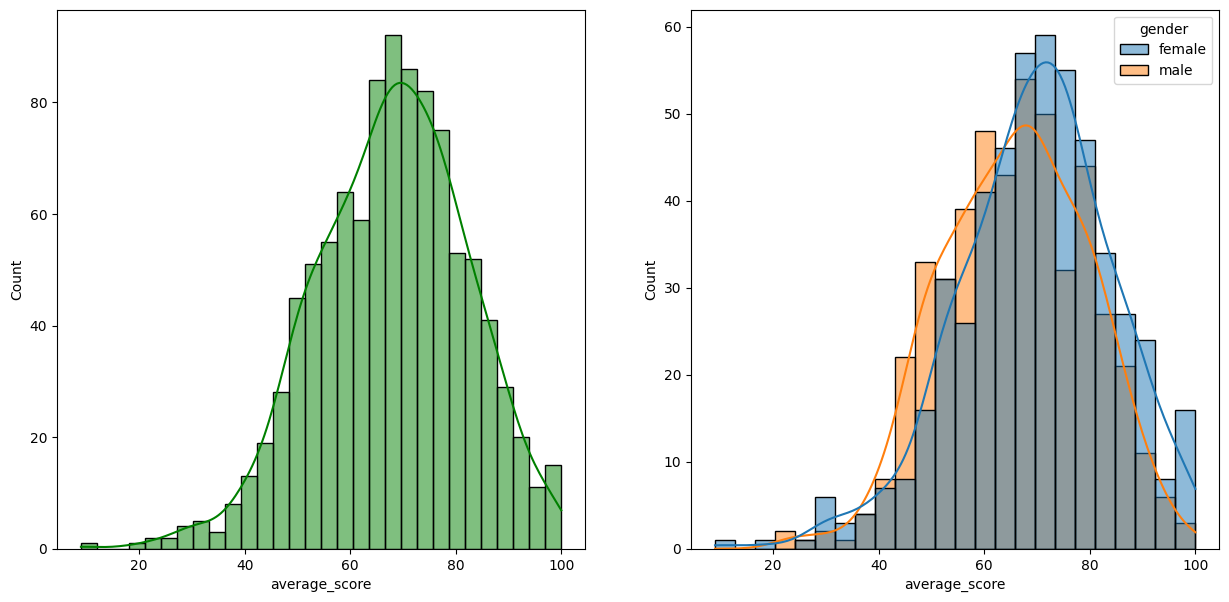

In [39]:
#vizualize the EDA that you have performed

fig, axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sn.histplot(data=df, x='average_score', bins=30, kde=True,color='g')
plt.subplot(122)
sn.histplot(data=df, x='average_score', kde=True, hue='gender')
plt.show()

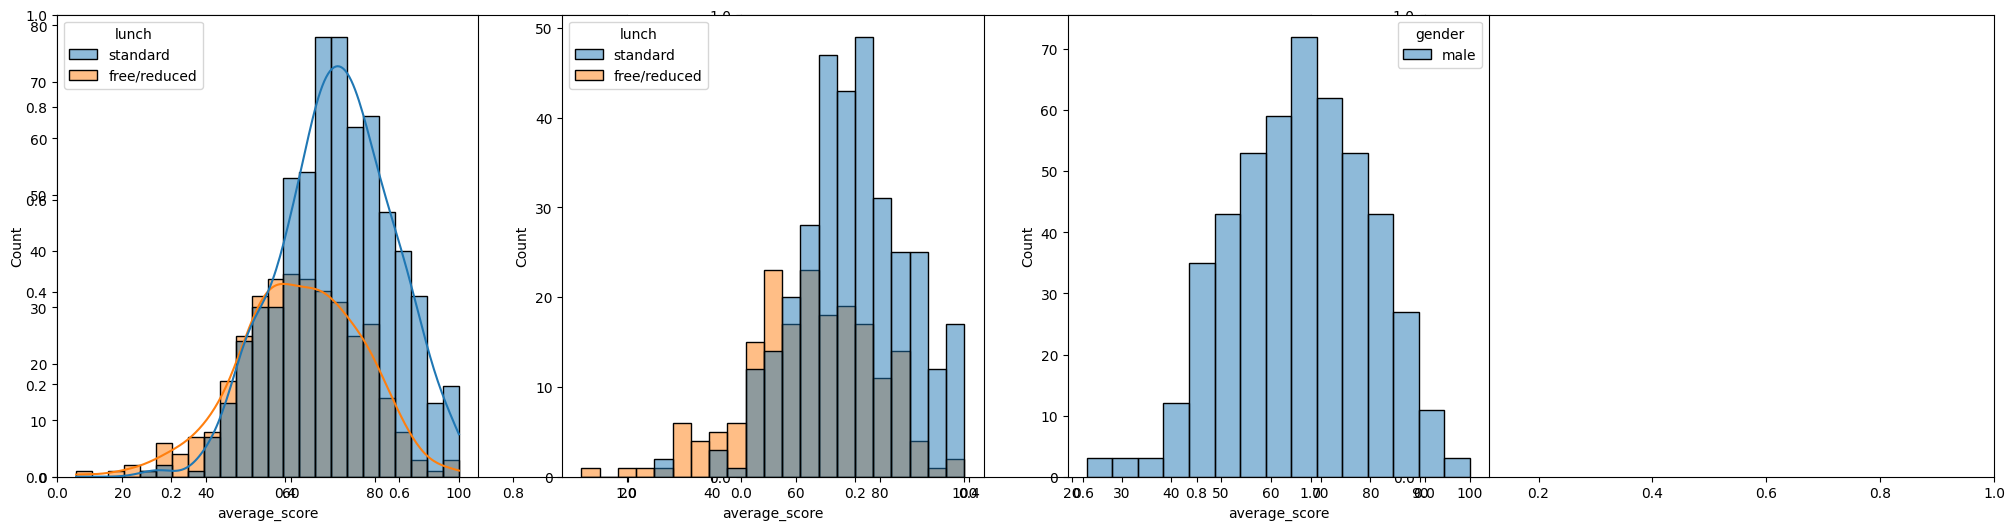

In [41]:
fig, axs = plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sn.histplot(data=df, x='average_score', kde=True,hue='lunch')
plt.subplot(142)
sn.histplot(data=df[df.gender=='female'], x='average_score', hue='lunch')
plt.subplot(143)
sn.histplot(data=df[df.gender=='male'],x='average_score', hue='gender')
plt.show()